# Análise de Redes Complexas: Ecossistema do YouTube (Estreito de Ormuz)

Este relatório apresenta uma investigação sobre as propriedades topológicas de uma rede construída a partir de vídeos relacionados ao **Estreito de Ormuz**. O foco é identificar padrões de disseminação, concentração de conteúdo e a influência dos canais dominantes.

**Objetivo:** Verificar a arquitetura da rede, identificando se a visibilidade é pulverizada ou concentrada em "hubs" de autoridade.

In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Configurações de visualização para o notebook
%matplotlib inline

## 1. Metodologia e Coleta de Dados
A extração foi realizada via **YouTube API**. Modelamos a rede como um grafo não direcionado $G = (V, E)$, onde cada vídeo é um vértice e as arestas conectam vídeos pertencentes ao mesmo canal.

In [2]:
# Carregar dados
df = pd.read_csv("../Api/data/raw/videos.csv")
df["views"] = pd.to_numeric(df["views"], errors="coerce").fillna(0)

# Para fins de demonstração, analisaremos o Cenário B (Top 250 vídeos)
# Você pode parametrizar este valor para alternar entre os cenários A e B
LIMIT = 250
df_analysis = df.sort_values(by="views", ascending=False).head(LIMIT)

print(f"Dataset carregado com {len(df_analysis)} vídeos para análise.")

Dataset carregado com 250 vídeos para análise.


## 2. Construção do Grafo e Cálculo de Métricas
Nesta etapa, criamos as "cliques" por canal. Matematicamente, o grau de um vértice $k$ é determinado por $n_c - 1$, onde $n_c$ é o número de vídeos do canal na amostra.

In [3]:
# 1. Instanciar o Grafo
G = nx.Graph()

# 2. Adicionar os vídeos como nós
G.add_nodes_from(df_analysis["video_id"])

# 3. Agrupar vídeos por canal para criar as arestas
# Cada canal formará uma 'clique' (todos os vídeos do mesmo canal se conectam)
grouped = df_analysis.groupby("channel")

for channel, group in grouped:
    videos = group["video_id"].tolist()
    
    # Conexões completas dentro do subgrupo do canal
    for i in range(len(videos)):
        for j in range(i + 1, len(videos)):
            G.add_edge(videos[i], videos[j])

# 4. Cálculo de Métricas de Rede
# Coeficiente de clustering e centralidades
avg_clustering = nx.average_clustering(G)
degree_centrality = nx.degree_centrality(G)
eigenvector_centrality = nx.eigenvector_centrality(G)

print(f"Grafo construído com sucesso!")
print(f"Métricas calculadas para o Cenário de {LIMIT} vídeos.")

Grafo construído com sucesso!
Métricas calculadas para o Cenário de 250 vídeos.


## 3. Resultados e Métricas Topológicas

Abaixo, apresentamos os indicadores quantitativos que descrevem a saúde e a estrutura da rede. O **Coeficiente de Clustering Médio** é fundamental para entender quão "fechadas" são as comunidades (canais) nesta rede.

In [4]:
# Exibição formatada das métricas
print("-" * 40)
print(f"ESTATÍSTICAS DO GRAFO (TOP {LIMIT})")
print("-" * 40)
print(f"Número de Vértices (Vídeos):  {G.number_of_nodes()}")
print(f"Número de Arestas (Conexões): {G.number_of_edges()}")
print(f"Clustering Médio:             {avg_clustering:.4f}")
print("-" * 40)

# Identificar os 5 vídeos mais centrais por grau
top_5_degree = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:5]
print("\nTop 5 Vídeos por Centralidade de Grau:")
for vid, val in top_5_degree:
    canal = df[df['video_id'] == vid]['channel'].values[0]
    print(f"- ID: {vid} | Canal: {canal} | Centralidade: {val:.4f}")

----------------------------------------
ESTATÍSTICAS DO GRAFO (TOP 250)
----------------------------------------
Número de Vértices (Vídeos):  250
Número de Arestas (Conexões): 718
Clustering Médio:             0.5960
----------------------------------------

Top 5 Vídeos por Centralidade de Grau:
- ID: 2lMLE8_bDHg | Canal: CNN Brasil | Centralidade: 0.1004
- ID: 2Bp4xoPeHug | Canal: CNN Brasil | Centralidade: 0.1004
- ID: 3hpQFiB0Kxc | Canal: CNN Brasil | Centralidade: 0.1004
- ID: 7yhkC930B0s | Canal: CNN Brasil | Centralidade: 0.1004
- ID: Wh4Lt_63K1s | Canal: CNN Brasil | Centralidade: 0.1004


## 4. Filtragem e Estética do Grafo
Para uma visualização clara do "núcleo de influência", filtramos os **50 nós mais importantes**. 
O tamanho dos nós será determinado por um peso híbrido entre **Centralidade de Grau** (importância na estrutura) e **Volume de Visualizações** (popularidade real).

In [5]:
# 1. Selecionar o Top 50 nós mais centrais
top_nodes = sorted(degree_centrality, key=degree_centrality.get, reverse=True)[:50]
G_small = G.subgraph(top_nodes)

# 2. Dicionários auxiliares para mapeamento
video_to_channel = dict(zip(df_analysis["video_id"], df_analysis["channel"]))
views_dict = dict(zip(df_analysis["video_id"], df_analysis["views"]))
max_views = max(views_dict.values()) if views_dict else 1

# 3. Mapeamento de cores por canal
channels_in_graph = sorted(set(video_to_channel[node] for node in G_small.nodes()))
color_map_dict = {channel: i for i, channel in enumerate(channels_in_graph)}

node_colors = [color_map_dict[video_to_channel[node]] for node in G_small.nodes()]

# 4. Cálculo do tamanho dos nós (Modelo Híbrido)
degree_small = nx.degree_centrality(G_small)
node_sizes = []

for node in G_small.nodes():
    c = degree_small[node]
    v_norm = views_dict[node] / max_views
    # Peso 50/50 entre estrutura e popularidade
    size = (0.5 * c + 0.5 * v_norm) * 3000
    node_sizes.append(size)

print(f"Subgrafo de visualização pronto com {len(G_small.nodes())} nós.")

Subgrafo de visualização pronto com 50 nós.


## 5. Print dos Grafos e geração de legendas
De forma a mostrar graficamente os dados analisádos, o codigo abaixo desenvolve o grafo em formato de imagem para visualização.

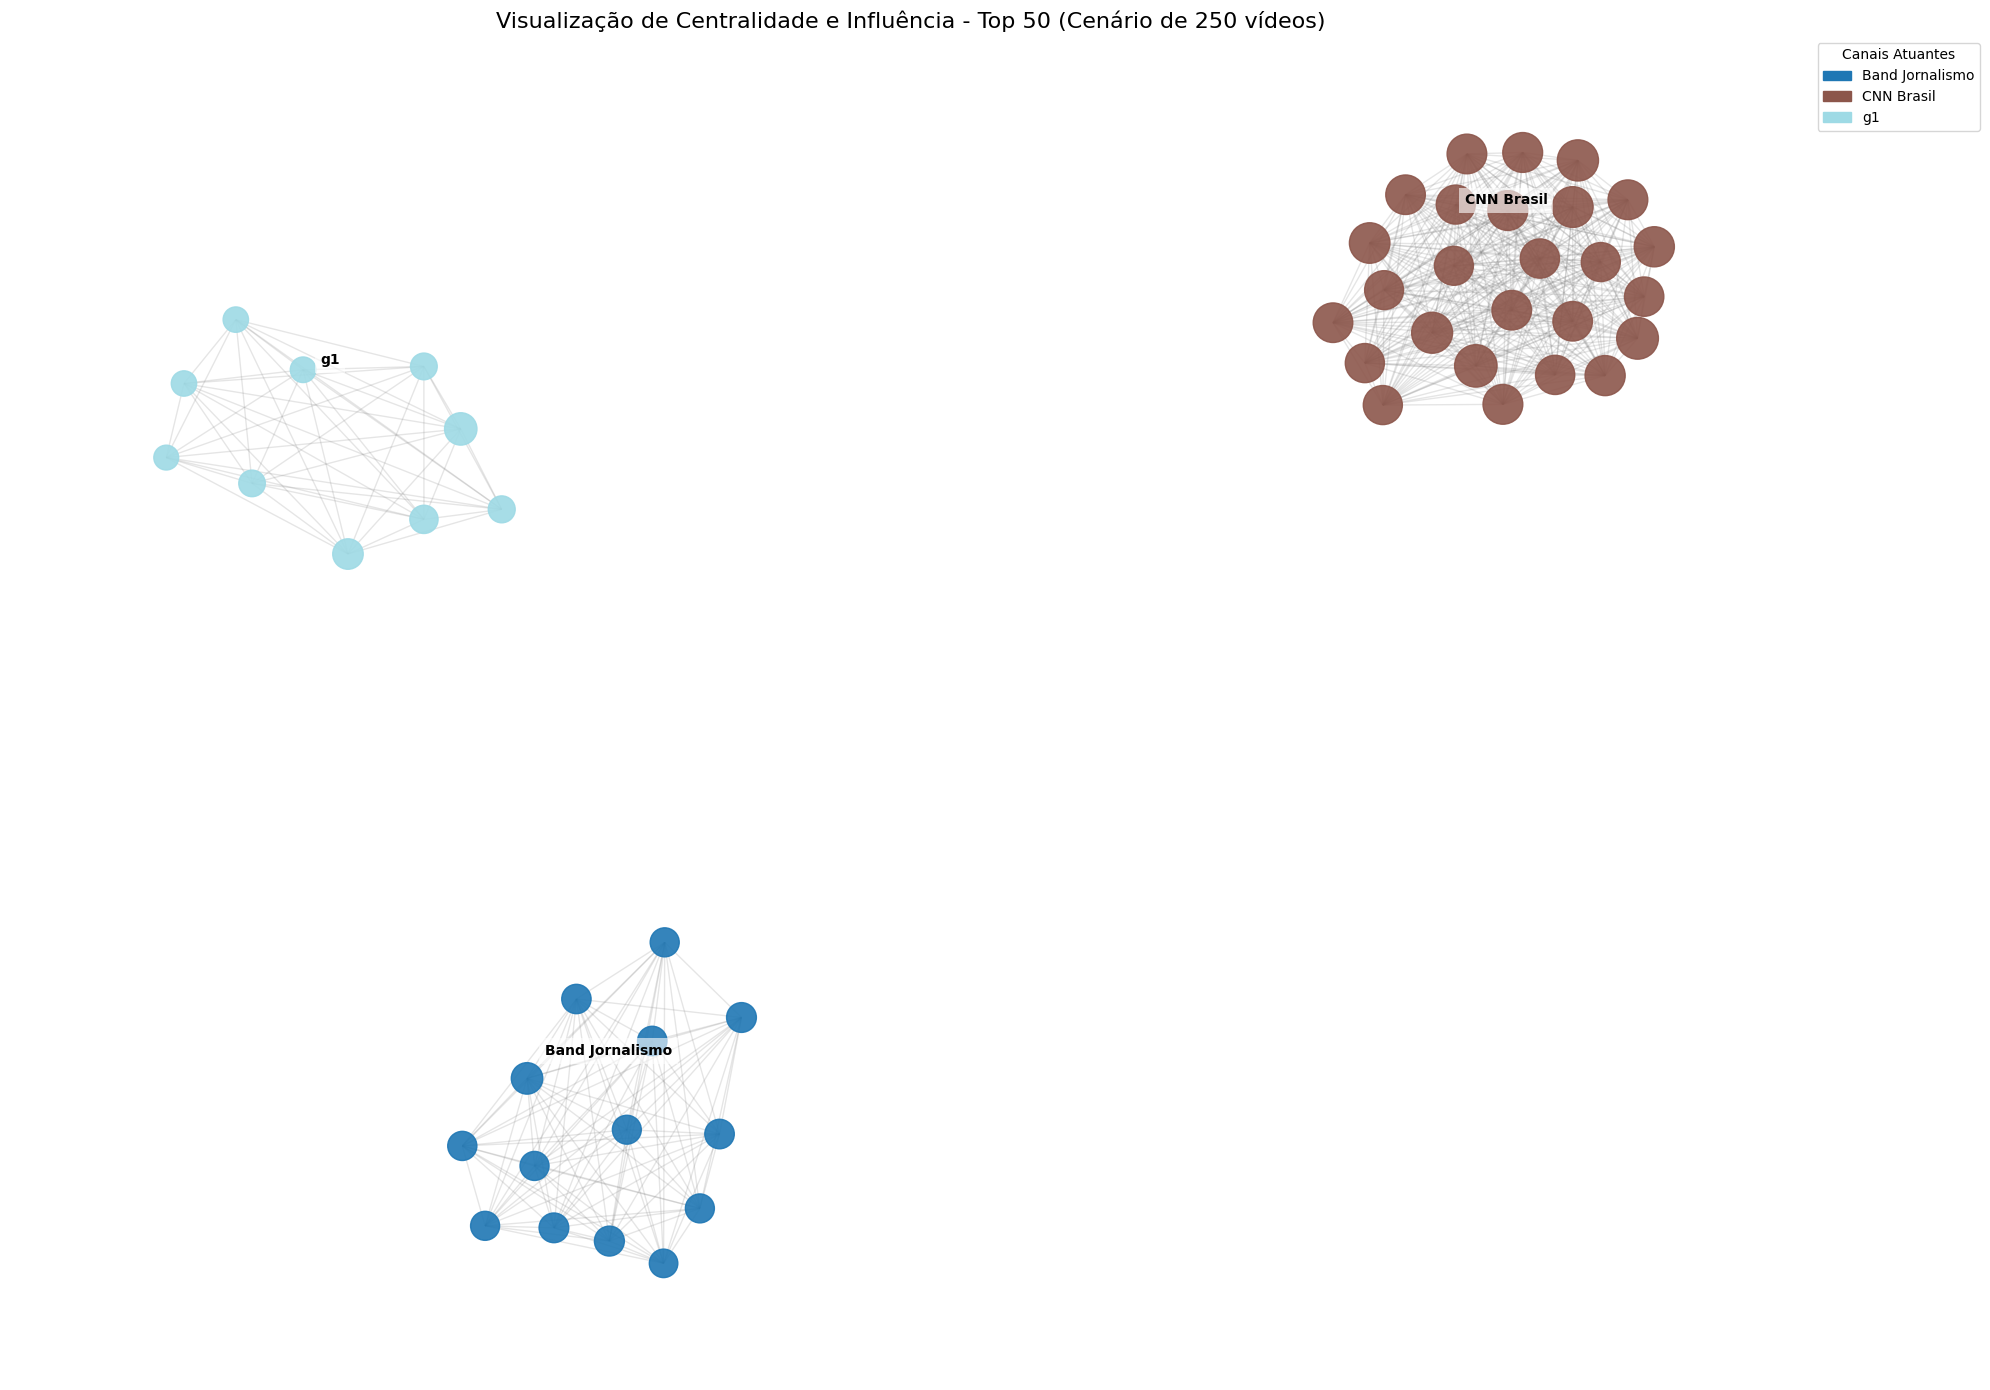

In [ ]:
plt.figure(figsize=(20, 14))

# Layout dinâmico (Spring Layout)
pos = nx.spring_layout(G_small, k=1.2, iterations=100, seed=42)

# Desenhar nós e arestas
nodes = nx.draw_networkx_nodes(G_small, pos, node_size=node_sizes, 
                               node_color=node_colors, cmap=plt.cm.tab20, alpha=0.9)
nx.draw_networkx_edges(G_small, pos, edge_color='gray', alpha=0.2, width=1)

# Adicionar labels nos clusters (canais)
components = list(nx.connected_components(G_small))
for comp in components:
    rep_node = list(comp)[0]
    channel_name = video_to_channel.get(rep_node, "Desconhecido")
    x = sum(pos[n][0] for n in comp) / len(comp)
    y = sum(pos[n][1] for n in comp) / len(comp)
    plt.text(x, y + 0.1, channel_name, fontsize=10, ha='center', fontweight='bold',
             bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

# Legenda e Título
legend_handles = [mpatches.Patch(color=plt.cm.tab20(i/(len(channels_in_graph)-1)), label=ch)
                  for ch, i in color_map_dict.items()]
plt.legend(handles=legend_handles, title="Canais Atuantes", loc='upper left', bbox_to_anchor=(1, 1))

plt.title(f"Visualização de Centralidade e Influência - Top 50 (Cenário de {LIMIT} vídeos)", fontsize=16)
plt.axis("off")
plt.tight_layout()
plt.show()

## 6. Instanciando o grafo para recolhimento de top 100 vídeos

In [8]:
LIMIT = 100
df_analysis = df.sort_values(by="views", ascending=False).head(LIMIT)


# 1. Instanciar o Grafo
G = nx.Graph()

# 2. Adicionar os vídeos como nós
G.add_nodes_from(df_analysis["video_id"])

# 3. Agrupar vídeos por canal para criar as arestas
# Cada canal formará uma 'clique' (todos os vídeos do mesmo canal se conectam)
grouped = df_analysis.groupby("channel")

for channel, group in grouped:
    videos = group["video_id"].tolist()
    
    # Conexões completas dentro do subgrupo do canal
    for i in range(len(videos)):
        for j in range(i + 1, len(videos)):
            G.add_edge(videos[i], videos[j])

# 4. Cálculo de Métricas de Rede
# Coeficiente de clustering e centralidades
avg_clustering = nx.average_clustering(G)
degree_centrality = nx.degree_centrality(G)
eigenvector_centrality = nx.eigenvector_centrality(G)

print(f"Grafo construído com sucesso!")
print(f"Métricas calculadas para o Cenário de {LIMIT} vídeos.")

Grafo construído com sucesso!
Métricas calculadas para o Cenário de 100 vídeos.


## 7. Novas Métricas - Top 100 vídeos

In [9]:
# Exibição formatada das métricas
print("-" * 40)
print(f"ESTATÍSTICAS DO GRAFO (TOP {LIMIT})")
print("-" * 40)
print(f"Número de Vértices (Vídeos):  {G.number_of_nodes()}")
print(f"Número de Arestas (Conexões): {G.number_of_edges()}")
print(f"Clustering Médio:             {avg_clustering:.4f}")
print("-" * 40)

# Identificar os 5 vídeos mais centrais por grau
top_5_degree = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:5]
print("\nTop 5 Vídeos por Centralidade de Grau:")
for vid, val in top_5_degree:
    canal = df[df['video_id'] == vid]['channel'].values[0]
    print(f"- ID: {vid} | Canal: {canal} | Centralidade: {val:.4f}")


# 1. Selecionar o Top 50 nós mais centrais
top_nodes = sorted(degree_centrality, key=degree_centrality.get, reverse=True)[:50]
G_small = G.subgraph(top_nodes)

# 2. Dicionários auxiliares para mapeamento
video_to_channel = dict(zip(df_analysis["video_id"], df_analysis["channel"]))
views_dict = dict(zip(df_analysis["video_id"], df_analysis["views"]))
max_views = max(views_dict.values()) if views_dict else 1

# 3. Mapeamento de cores por canal
channels_in_graph = sorted(set(video_to_channel[node] for node in G_small.nodes()))
color_map_dict = {channel: i for i, channel in enumerate(channels_in_graph)}

node_colors = [color_map_dict[video_to_channel[node]] for node in G_small.nodes()]

# 4. Cálculo do tamanho dos nós (Modelo Híbrido)
degree_small = nx.degree_centrality(G_small)
node_sizes = []

for node in G_small.nodes():
    c = degree_small[node]
    v_norm = views_dict[node] / max_views
    # Peso 50/50 entre estrutura e popularidade
    size = (0.5 * c + 0.5 * v_norm) * 3000
    node_sizes.append(size)

print(f"Subgrafo de visualização pronto com {len(G_small.nodes())} nós.")

----------------------------------------
ESTATÍSTICAS DO GRAFO (TOP 100)
----------------------------------------
Número de Vértices (Vídeos):  100
Número de Arestas (Conexões): 69
Clustering Médio:             0.3600
----------------------------------------

Top 5 Vídeos por Centralidade de Grau:
- ID: 2lMLE8_bDHg | Canal: CNN Brasil | Centralidade: 0.0606
- ID: 2Bp4xoPeHug | Canal: CNN Brasil | Centralidade: 0.0606
- ID: 3hpQFiB0Kxc | Canal: CNN Brasil | Centralidade: 0.0606
- ID: 7yhkC930B0s | Canal: CNN Brasil | Centralidade: 0.0606
- ID: Wh4Lt_63K1s | Canal: CNN Brasil | Centralidade: 0.0606
Subgrafo de visualização pronto com 50 nós.


## 8. Plotagem novo grafo - Top 100 vídeos

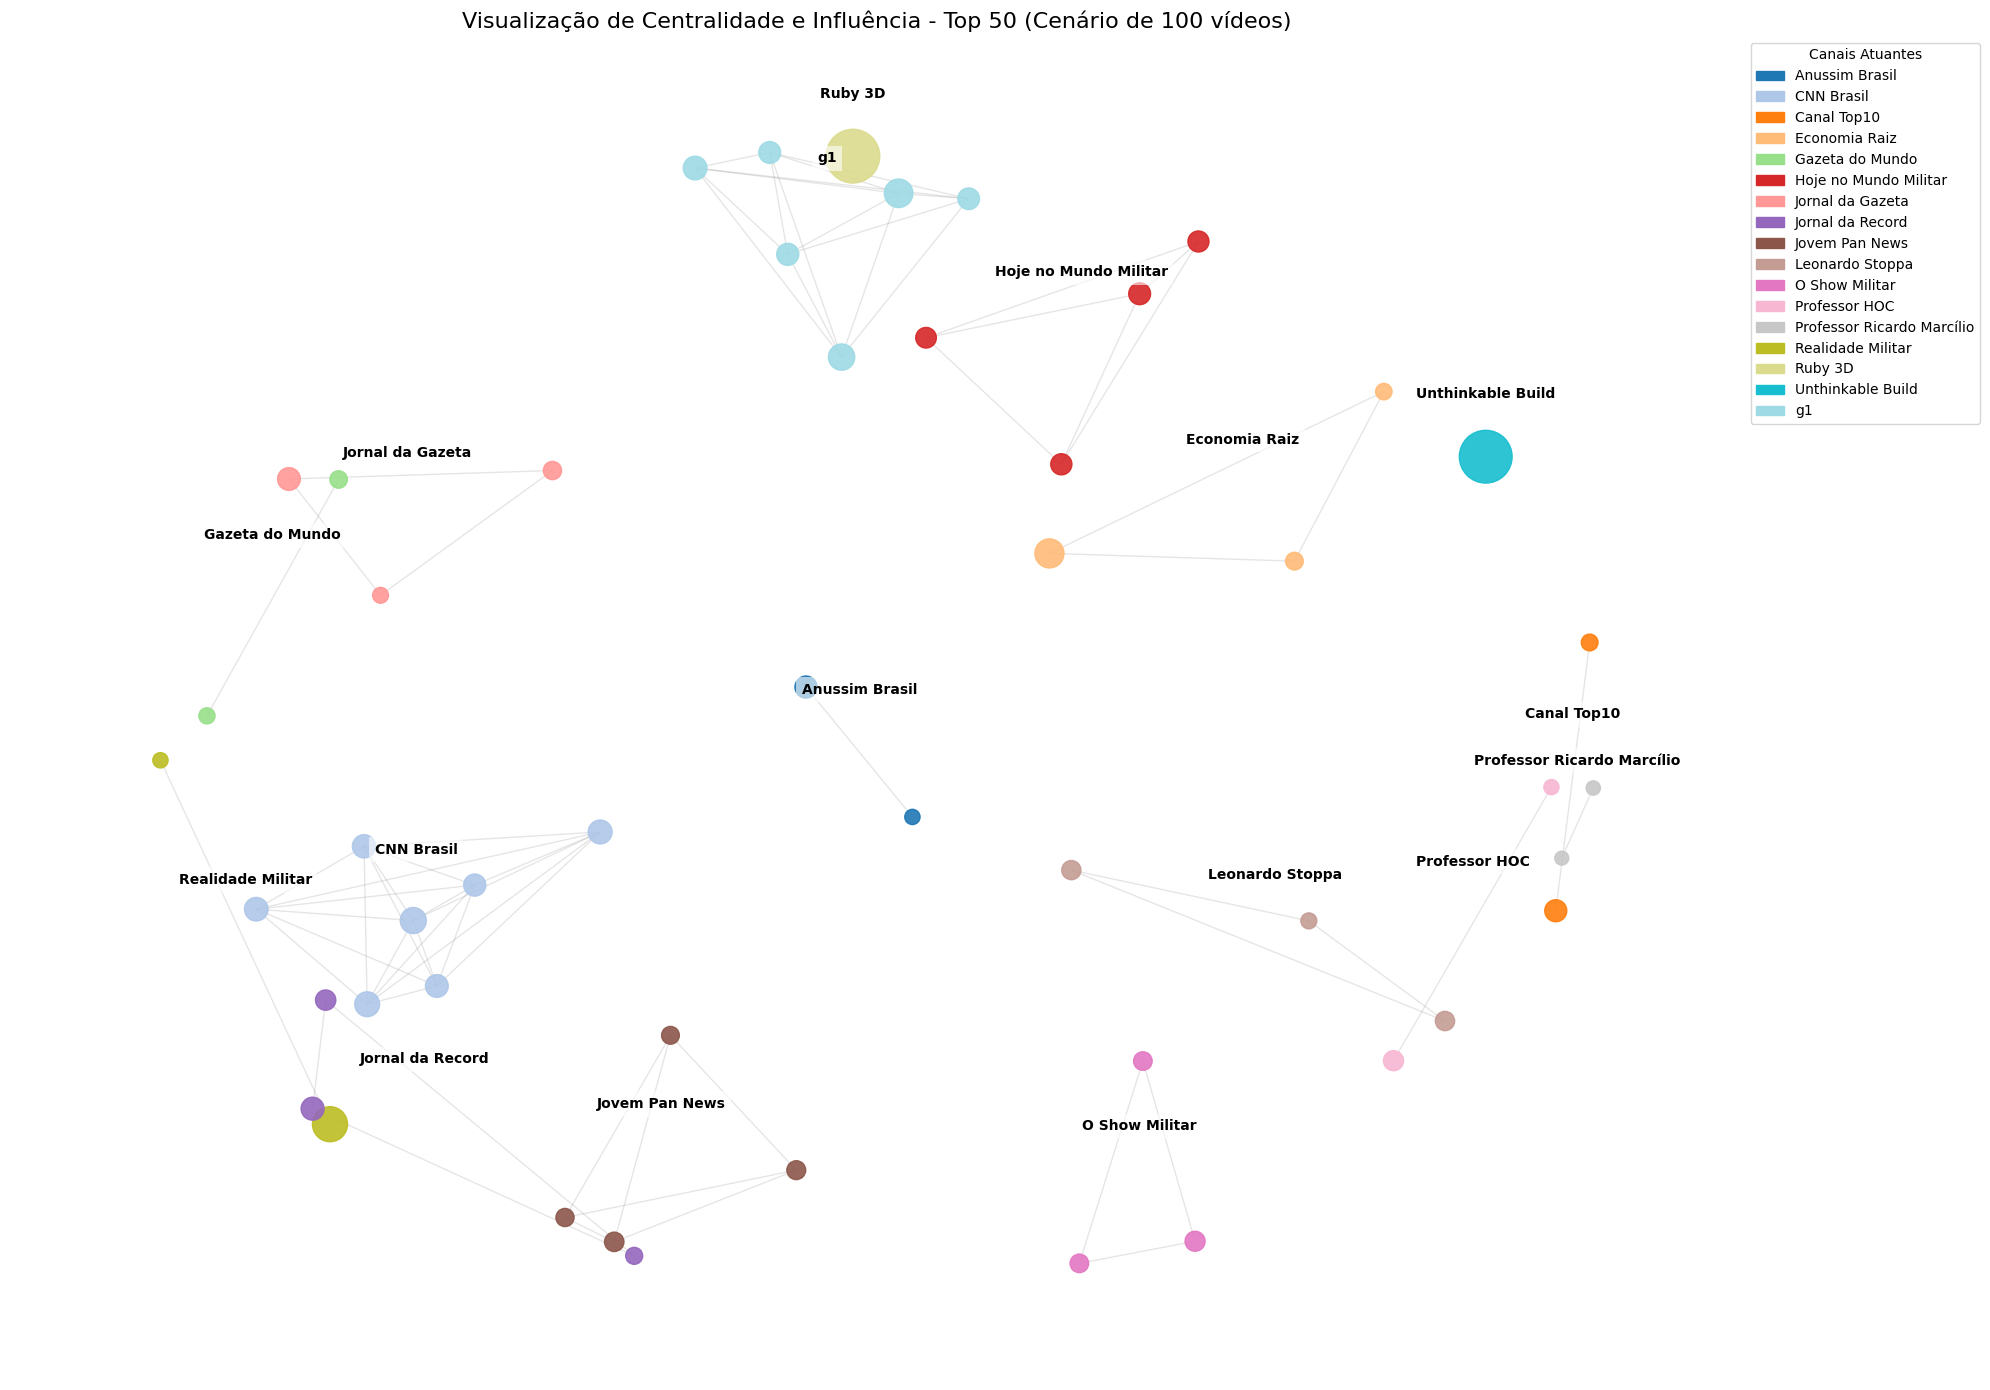

In [10]:
plt.figure(figsize=(20, 14))

# Layout dinâmico (Spring Layout)
pos = nx.spring_layout(G_small, k=1.2, iterations=100, seed=42)

# Desenhar nós e arestas
nodes = nx.draw_networkx_nodes(G_small, pos, node_size=node_sizes, 
                               node_color=node_colors, cmap=plt.cm.tab20, alpha=0.9)
nx.draw_networkx_edges(G_small, pos, edge_color='gray', alpha=0.2, width=1)

# Adicionar labels nos clusters (canais)
components = list(nx.connected_components(G_small))
for comp in components:
    rep_node = list(comp)[0]
    channel_name = video_to_channel.get(rep_node, "Desconhecido")
    x = sum(pos[n][0] for n in comp) / len(comp)
    y = sum(pos[n][1] for n in comp) / len(comp)
    plt.text(x, y + 0.1, channel_name, fontsize=10, ha='center', fontweight='bold',
             bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

# Legenda e Título
legend_handles = [mpatches.Patch(color=plt.cm.tab20(i/(len(channels_in_graph)-1)), label=ch)
                  for ch, i in color_map_dict.items()]
plt.legend(handles=legend_handles, title="Canais Atuantes", loc='upper left', bbox_to_anchor=(1, 1))

plt.title(f"Visualização de Centralidade e Influência - Top 50 (Cenário de {LIMIT} vídeos)", fontsize=16)
plt.axis("off")
plt.tight_layout()
plt.show()

## 9. Conclusões da Análise
A partir desta análise de redes, observamos que o debate sobre o **Estreito de Ormuz** no YouTube não é distribuído de forma equânime. 

1. **Predomínio de Hubs:** A estrutura livre de escala indica que a atenção do usuário é capturada por poucos produtores que saturam o ranking com múltiplos vídeos.
2. **Formação de Cliques:** O alto coeficiente de clustering confirma que, uma vez dentro de um canal, o usuário tende a ser exposto a uma rede fechada de conteúdos do mesmo autor.
3. **Poder de Disseminação:** Canais com alta centralidade de autovetor não possuem apenas muitos vídeos, mas possuem os vídeos que dominam as buscas e visualizações, ditando o fluxo de informação sobre o tema geopolítico.

### 📄 Documentação Complementar
Para uma leitura detalhada dos fundamentos teóricos, contexto geopolítico e conclusões acadêmicas desta análise, acesse o relatório completo:
[**Relatório Técnico - Análise de Redes: Estreito de Ormuz**](https://drive.google.com/file/d/1D6d8h6kJXp0A6Aj7KEshlX1Wy6vgA5Va/view?usp=sharing)
---